# II.3 Aplicações do cálculo multivariado

Com as ferramentas desenvolvidas em [II.2](II.2_limites_e_derivadas_em_multiplas_variaveis.ipynb) — derivadas parciais, regra da cadeia, derivada direcional e gradiente — podemos agora explorar algumas aplicações clássicas do cálculo de várias variáveis: a **aproximação linear** de uma função pelo seu **plano tangente**, a **propagação de erros** por meio da diferencial, e as **taxas relacionadas**. (A busca por máximos e mínimos, outra aplicação importante das derivadas parciais, é o assunto do próximo notebook, [II.4](II.4_maximos_e_minimos_funcoes_de_duas_variaveis.ipynb).)

Assim como no notebook anterior, vamos alternar entre cálculos **simbólicos** (`sympy`), que fornecem fórmulas exatas, e cálculos **numéricos** (`numpy`), que permitem avaliar, comparar e visualizar essas fórmulas em situações concretas.

**Exemplo 1: (Vetor normal)** Seja $z=f(x, y)$, podemos reescrever como uma função implícita $
F(x, y, z)=f(x, y)-z=0$. O vetor normal à superfície é o gradiente
$$
\nabla F(x, y, z)=\left(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y},-1\right)
$$

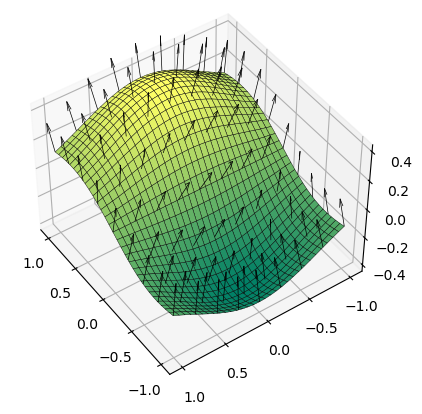

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x, y = np.mgrid[-1:1:31j, -1:1:31j]
xs, ys = np.mgrid[-1:1:9j, -1:1:9j]

z = x*np.exp(-x**2 - y**2)
zs = xs*np.exp(-xs**2 - ys**2)
u = -(1 - 2*xs**2)*np.exp(-xs**2 - ys**2)
v = 2*ys*zs
w = np.ones_like(xs)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(azim=145, elev=45)
ax.plot_surface(x, y, z, rstride=1, cstride=1, cmap="summer", lw=0.3, edgecolors="k")
ax.quiver(xs, ys, zs, u, v, w, colors='k', pivot='tail', length=0.2, lw=0.5)
plt.show()

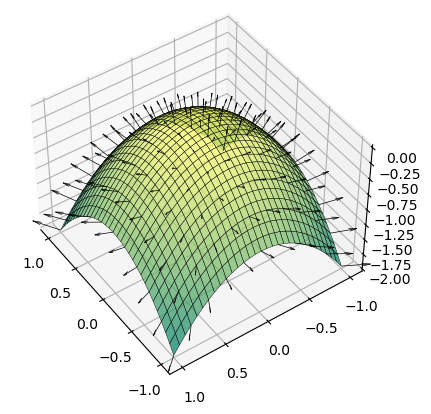

In [2]:
x, y = np.mgrid[-1:1:31j, -1:1:31j]
z = -x**2 - y**2

xs, ys = np.mgrid[-1:1:11j, -1:1:11j]
zs = -xs**2 - ys**2
u = 2*xs
v = 2*ys
w = np.ones_like(xs)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x, y, z, rstride=1, cstride=1, cmap="summer", lw=0.3, edgecolors="k", alpha=0.7)
ax.quiver(xs, ys, zs, u, v, w, colors='k', length=0.1, lw=0.5)

ax.view_init(azim=145, elev=45)
plt.show()

## Plano tangente a uma superfície

Considere uma superfície dada por $z=f(x,y)$, com $f$ diferenciável em $(a,b)$. O **plano tangente** a essa superfície no ponto $(a,b,f(a,b))$ é o plano que melhor aproxima a superfície nesse ponto, dado por

$$ z = f(a,b) + f_x(a,b)\,(x-a) + f_y(a,b)\,(y-b) $$

O vetor

$$ \mathbf n = \big(f_x(a,b),\, f_y(a,b),\, -1\big) $$

é normal (perpendicular) à superfície nesse ponto, o que permite também escrever a **reta normal** à superfície, na forma paramétrica

$$
(x,y,z) = (a,b,f(a,b)) + s\cdot \mathbf n, \qquad s\in\mathbb{R}
$$

**Exemplo 2:** Vamos obter o plano tangente ao paraboloide $f(x,y) = x^2+y^2$ no ponto $(1,1,f(1,1))$, usando `sympy` para os cálculos simbólicos e visualizando o resultado com `matplotlib`.

In [3]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x, y = sp.symbols('x y')
f_exp = x**2 + y**2

a, b = 1, 1
fx = sp.diff(f_exp, x)
fy = sp.diff(f_exp, y)

f_ab = f_exp.subs({x: a, y: b})
fx_ab = fx.subs({x: a, y: b})
fy_ab = fy.subs({x: a, y: b})

plano = f_ab + fx_ab*(x-a) + fy_ab*(y-b)
sp.Eq(sp.Symbol('z'), sp.expand(plano))

Eq(z, 2*x + 2*y - 2)

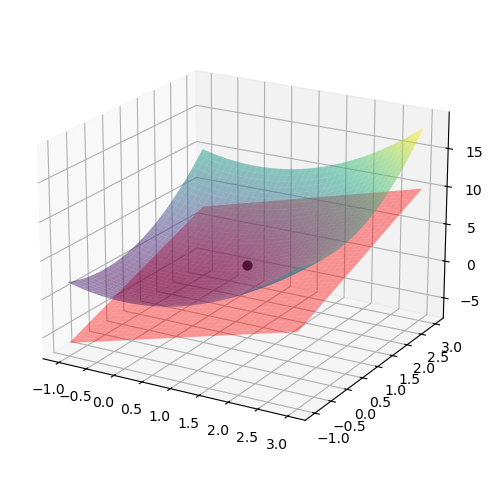

In [4]:
f = sp.lambdify([x, y], f_exp)
plano_fn = sp.lambdify([x, y], plano)

xi, yi = np.meshgrid(np.linspace(-1, 3, 40), np.linspace(-1, 3, 40))

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(xi, yi, f(xi, yi), alpha=0.5, cmap='viridis')
ax.plot_surface(xi, yi, plano_fn(xi, yi), alpha=0.4, color='red')
ax.scatter([a], [b], [float(f_ab)], color='black', s=40)
ax.view_init(20, -60)
plt.show()

O plano vermelho toca a superfície exatamente no ponto $(1,1,2)$ e a aproxima bem em sua vizinhança — quanto mais distante desse ponto, maior a diferença entre a superfície e o plano.

## Aproximação linear (linearização)

A equação do plano tangente também define a **aproximação linear** de $f$ em torno de $(a,b)$:

$$ L(x,y) = f(a,b) + f_x(a,b)(x-a) + f_y(a,b)(y-b) \approx f(x,y) $$

válida para $(x,y)$ próximo de $(a,b)$. Essa aproximação é muito usada quando calcular $f(x,y)$ exatamente é difícil ou custoso, mas seus valores e derivadas em $(a,b)$ são conhecidos.

**Exemplo 3:** Vamos estimar $\sqrt{(4{,}05)^2 + (2{,}98)^2}$ usando a linearização de $f(x,y)=\sqrt{x^2+y^2}$ em torno do ponto $(4,3)$, sem calcular a raiz diretamente, e comparar com o valor exato (numérico).

In [5]:
x, y = sp.symbols('x y')
f_exp = sp.sqrt(x**2 + y**2)

a, b = 4, 3
fx_ab = sp.diff(f_exp, x).subs({x: a, y: b})
fy_ab = sp.diff(f_exp, y).subs({x: a, y: b})
f_ab = f_exp.subs({x: a, y: b})

L = f_ab + fx_ab*(x-a) + fy_ab*(y-b)
L_num = L.subs({x: 4.05, y: 2.98})
print('Aproximação linear: L(4.05, 2.98) =', float(L_num))

f_exato = np.sqrt(4.05**2 + 2.98**2)
print('Valor exato (numérico):        ', f_exato)
print('Erro absoluto:', abs(float(L_num) - f_exato))

Aproximação linear: L(4.05, 2.98) = 5.0280000000000005
Valor exato (numérico):         5.028210417235937
Erro absoluto: 0.00021041723593651085


O erro é muito pequeno, pois $(4{,}05;\,2{,}98)$ está bem próximo do ponto $(4,3)$ em torno do qual linearizamos. Note a distinção entre os dois cálculos: a fórmula de $L(x,y)$ foi obtida **simbolicamente**, de forma exata, mas o valor "exato" de $f(4{,}05;\,2{,}98)$ só pôde ser obtido **numericamente**, pois envolve uma raiz quadrada irracional.

## Diferencial total e propagação de erros

A **diferencial total** de $z=f(x,y)$ é dada por

$$ dz = f_x(x,y)\,dx + f_y(x,y)\,dy $$

e representa a variação aproximada de $z$ quando $x$ varia de $dx$ e $y$ varia de $dy$ (variações pequenas). Essa ideia é muito usada para estimar o **erro propagado** em um cálculo, a partir de erros (ou incertezas) conhecidos nas variáveis de entrada.

**Exemplo 4:** O volume de um cilindro circular reto é $V=\pi r^2 h$. Medimos o raio como $r=4\,\text{cm}$ e a altura como $h=10\,\text{cm}$, cada medida com um erro máximo de $0{,}05\,\text{cm}$. Vamos estimar o erro máximo propagado no cálculo do volume usando a diferencial, e comparar com uma estimativa numérica por amostragem.

In [6]:
r, h = sp.symbols('r h')
V_exp = sp.pi*r**2*h

dVdr = sp.diff(V_exp, r)
dVdh = sp.diff(V_exp, h)

r0, h0 = 4, 10
dr, dh = 0.05, 0.05

dV = dVdr.subs({r: r0, h: h0})*dr + dVdh.subs({r: r0, h: h0})*dh
print('Erro máximo estimado pela diferencial: dV =', float(dV), 'cm^3')

Erro máximo estimado pela diferencial: dV = 15.079644737231007 cm^3


In [7]:
# estimativa numérica por amostragem direta, dentro da faixa de erro
V = lambda r, h: np.pi*r**2*h

rng = np.random.default_rng(0)
rs = r0 + rng.uniform(-dr, dr, 200000)
hs = h0 + rng.uniform(-dh, dh, 200000)

V0 = V(r0, h0)
delta_V = np.abs(V(rs, hs) - V0)

print('Maior variação de V observada (amostragem numérica):', delta_V.max())

Maior variação de V observada (amostragem numérica): 15.177157831265845


A estimativa obtida com a diferencial (cálculo simbólico, baseado na aproximação linear) é bem próxima do valor máximo observado numericamente por amostragem direta — a diferencial funciona bem porque os erros $dr$ e $dh$ são pequenos comparados a $r_0$ e $h_0$.

## Taxas relacionadas

Um problema de **taxas relacionadas** ocorre quando duas ou mais grandezas variam com o tempo e estão relacionadas por uma equação; conhecendo a taxa de variação de algumas delas, queremos encontrar a taxa de variação das demais. A ferramenta usada é a **regra da cadeia**.

**Exemplo 5:** Um tanque cônico, com o vértice para baixo, está sendo preenchido com água. O raio $r$ da superfície da água e a altura $h$ da água mantêm a proporção fixa $r=h/2$, e o volume de água é $V=\frac{1}{3}\pi r^2 h$. Sabendo que a água é despejada a uma taxa de $2\,\text{m}^3/\text{min}$, vamos determinar a taxa de variação da altura $\dfrac{dh}{dt}$ no instante em que $h=3\,\text{m}$.

In [8]:
t = sp.symbols('t')
h_t = sp.Function('h')(t)
r_t = h_t/2

V_t = sp.Rational(1, 3)*sp.pi*r_t**2*h_t
V_t = sp.simplify(V_t)
display(V_t)

dVdt = sp.diff(V_t, t)
display(dVdt)

pi*h(t)**3/12

pi*h(t)**2*Derivative(h(t), t)/4

In [9]:
dhdt = sp.symbols('dhdt')

eq = sp.Eq(dVdt.subs(sp.Derivative(h_t, t), dhdt), 2)
eq_h3 = eq.subs(h_t, 3)
display(eq_h3)

sp.solve(eq_h3, dhdt)

Eq(9*pi*dhdt/4, 2)

[8/(9*pi)]

Portanto, no instante em que a altura da água é $3\,\text{m}$, ela está subindo a uma taxa de aproximadamente $0{,}28\,\text{m/min}$.

### Atividades:

**1.** Determine o plano tangente e a reta normal à superfície $z=e^{-x^2-y^2}$ no ponto $(0,0,1)$. Plote a superfície e o plano tangente juntos, como no Exemplo 2.

In [10]:
# Cole e/ou escreva seu código aqui

**2.** Use a aproximação linear de $f(x,y) = \ln(x-3y)$ em torno do ponto $(7,2)$ para estimar $f(6{,}9;\,2{,}06)$. Compare com o valor exato calculado numericamente, como no Exemplo 3.

In [11]:
# Cole e/ou escreva seu código aqui

**3.** As dimensões de uma caixa retangular são medidas como $x=75\,\text{cm}$, $y=60\,\text{cm}$ e $z=40\,\text{cm}$, cada uma com erro possível de $0{,}2\,\text{cm}$. Use a diferencial para estimar o erro máximo propagado no cálculo do volume $V=xyz$. Confirme sua estimativa com uma amostragem numérica, como no Exemplo 4.

In [12]:
# Cole e/ou escreva seu código aqui

**4.** (Taxas relacionadas) Um ponto se move ao longo da curva de interseção do paraboloide $z=x^2+y^2$ com o plano $y=2x$. Se $\dfrac{dx}{dt}=3$, determine $\dfrac{dz}{dt}$ no instante em que $x=1$, usando a regra da cadeia com `sympy`, como no Exemplo 5.

In [13]:
# Cole e/ou escreva seu código aqui

**5.** (Simbólico × numérico) Escolha uma função $f(x,y)$ e um ponto $(a,b)$ de sua preferência. Calcule a aproximação linear $L(x,y)$ simbolicamente. Em seguida, gere uma malha numérica de pontos em torno de $(a,b)$ e plote (com `matplotlib`, usando `contourf` ou uma superfície 3D) o erro absoluto $|f(x,y)-L(x,y)|$. O que acontece com o erro conforme o ponto se afasta de $(a,b)$?

In [14]:
# Cole e/ou escreva seu código aqui

### Referências

GUIDORIZZI, Hamilton L. Um Curso de Cálculo - Volume 2. 6. ed. Rio de Janeiro: LTC, 2018.

STEWART, James; CLEGG, Daniel; WATSON, Saleem. Cálculo v.2. 6. ed. Porto Alegre: +A Educação - Cengage Learning Brasil, 2022.

THOMAS, G. B.; WEIR, M. D. e HASS, J. Cálculo Vol.2. Pearson, ed 12, 2012.
